In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from pathlib import Path

print(Path.cwd())

c:\Users\Sreoshi\anomaly-detection\notebooks


In [11]:
from pathlib import Path

data_path = Path("../data/raw/abohar_weather.csv")

print(data_path.resolve())
print(data_path.exists())

df = pd.read_csv(data_path, skiprows=2)

df.head()

C:\Users\Sreoshi\anomaly-detection\data\raw\abohar_weather.csv
True


,time,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
0,2020-01-01T00:00,3.0,96,1021.5
1,2020-01-01T01:00,2.5,97,1021.0
2,2020-01-01T02:00,1.9,98,1021.0
3,2020-01-01T03:00,1.7,98,1021.1
4,2020-01-01T04:00,1.5,99,1021.1


In [12]:
df["time"] = pd.to_datetime(df["time"])

df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
0,2020-01-01 00:00:00,3.0,96,1021.5
1,2020-01-01 01:00:00,2.5,97,1021.0
2,2020-01-01 02:00:00,1.9,98,1021.0
3,2020-01-01 03:00:00,1.7,98,1021.1
4,2020-01-01 04:00:00,1.5,99,1021.1


In [13]:
df = df.rename(columns={
    "time": "timestamp",
    "temperature_2m": "temperature",
    "relative_humidity_2m": "humidity",
    "pressure_msl": "pressure"
})

df.head()

,timestamp,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
0,2020-01-01 00:00:00,3.0,96,1021.5
1,2020-01-01 01:00:00,2.5,97,1021.0
2,2020-01-01 02:00:00,1.9,98,1021.0
3,2020-01-01 03:00:00,1.7,98,1021.1
4,2020-01-01 04:00:00,1.5,99,1021.1


In [14]:
df.shape


(43848, 4)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   timestamp                 43848 non-null  datetime64[us]
 1   temperature_2m (°C)       43848 non-null  float64       
 2   relative_humidity_2m (%)  43848 non-null  int64         
 3   pressure_msl (hPa)        43848 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1)
memory usage: 1.3 MB


In [16]:
df.isnull().sum()

timestamp                   0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
pressure_msl (hPa)          0
dtype: int64

In [17]:
df.describe()

,timestamp,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
count,43848,43848.000000,43848.000000,43848.000000
mean,2022-07-02 11:30:00,24.716366,58.486430,1008.306735
min,2020-01-01 00:00:00,1.500000,5.000000,989.200000
25%,2021-04-01 17:45:00,18.000000,41.000000,1001.900000
50%,2022-07-02 11:30:00,26.400000,60.000000,1008.000000
75%,2023-10-02 05:15:00,31.300000,77.000000,1015.000000
max,2024-12-31 23:00:00,47.300000,100.000000,1027.200000
std,NaN,8.793384,22.909271,7.647973


In [18]:
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Start: 2020-01-01 00:00:00
End: 2024-12-31 23:00:00


In [19]:
df["timestamp"].duplicated().sum()

np.int64(0)

In [20]:
df["timestamp"].diff().value_counts().head()

timestamp
0 days 01:00:00    43847
Name: count, dtype: int64

In [21]:
df = df.rename(columns={
    "temperature_2m (°C)": "temperature",
    "relative_humidity_2m (%)": "humidity",
    "pressure_msl (hPa)": "pressure"
})

df.columns

Index(['timestamp', 'temperature', 'humidity', 'pressure'], dtype='str')

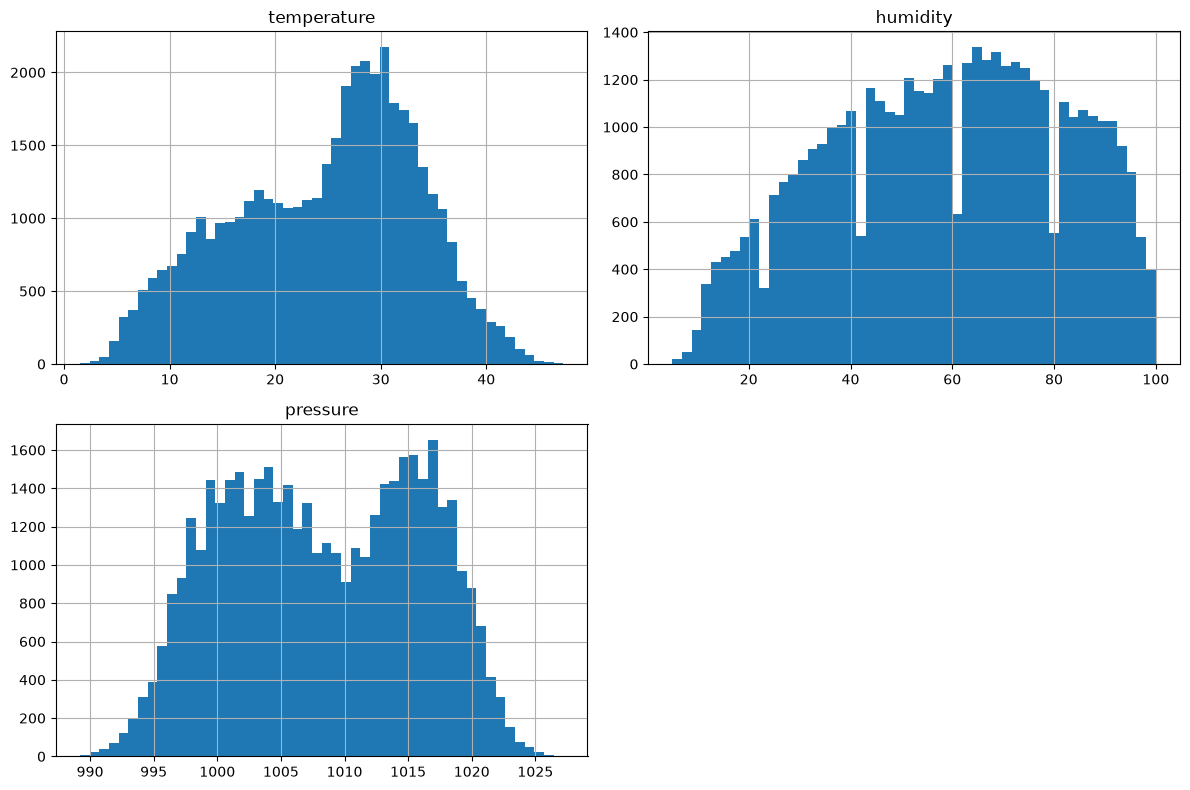

In [22]:
df[["temperature", "humidity", "pressure"]].hist(
    bins=50,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

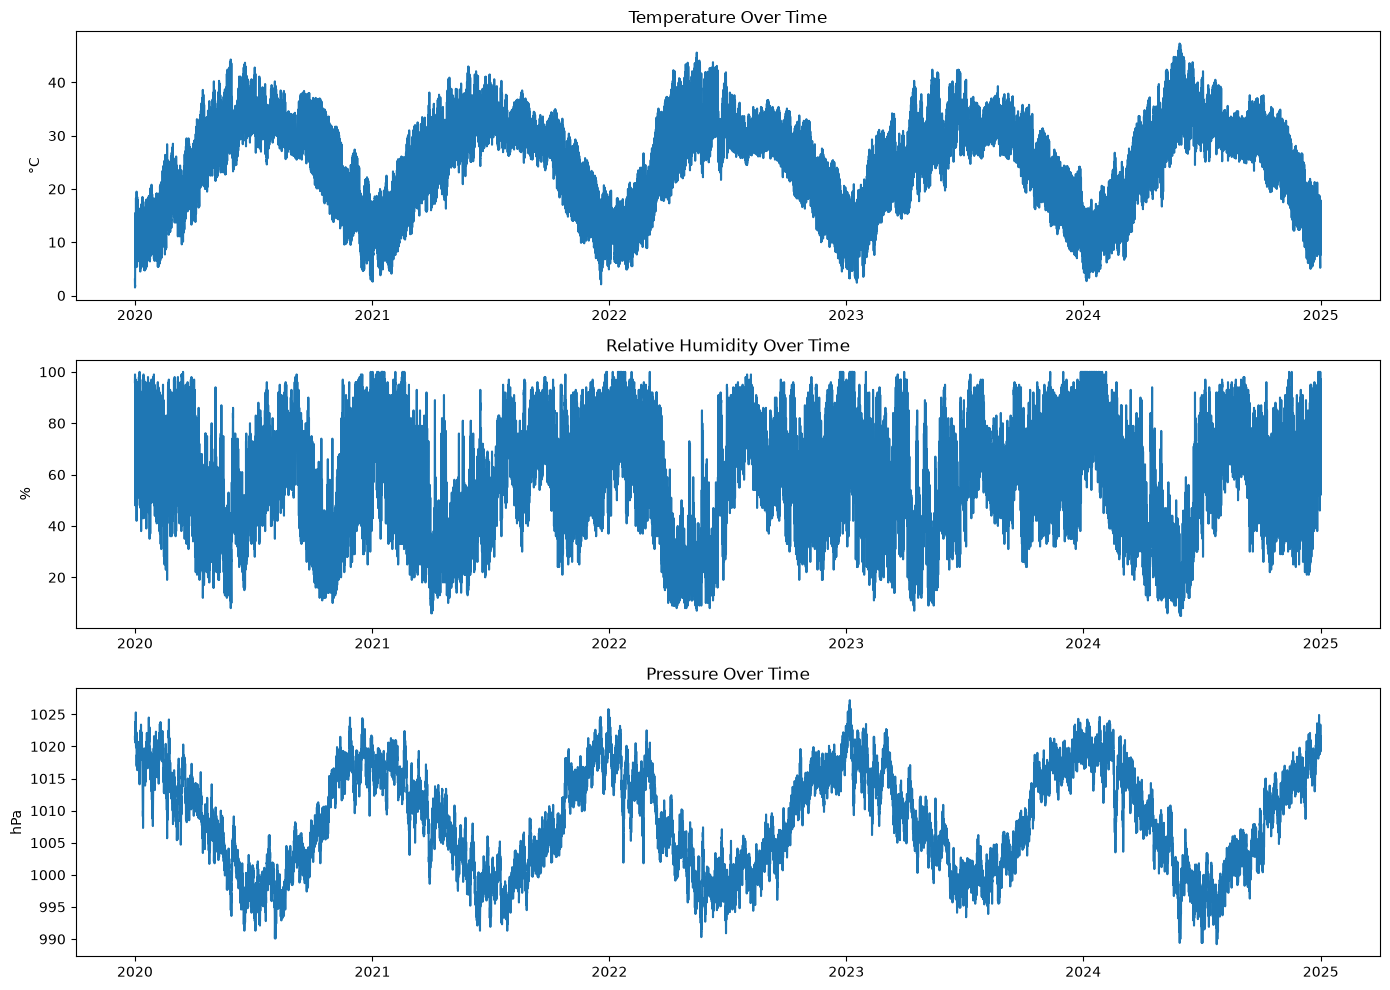

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df["timestamp"], df["temperature"])
axes[0].set_title("Temperature Over Time")
axes[0].set_ylabel("°C")

axes[1].plot(df["timestamp"], df["humidity"])
axes[1].set_title("Relative Humidity Over Time")
axes[1].set_ylabel("%")

axes[2].plot(df["timestamp"], df["pressure"])
axes[2].set_title("Pressure Over Time")
axes[2].set_ylabel("hPa")

plt.tight_layout()
plt.show()

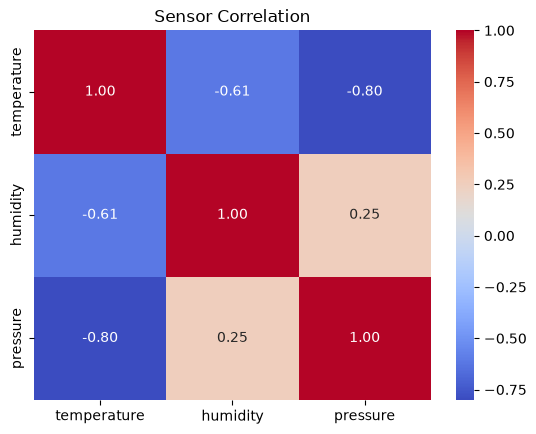

In [24]:
corr = df[["temperature", "humidity", "pressure"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Sensor Correlation")
plt.show()

In [25]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["year"] = df["timestamp"].dt.year

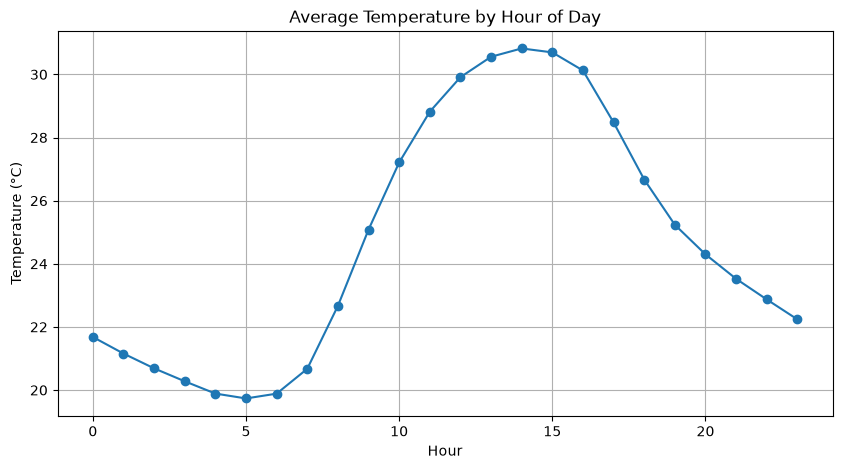

In [26]:
hourly_temp = df.groupby("hour")["temperature"].mean()

hourly_temp.plot(figsize=(10, 5), marker="o")

plt.title("Average Temperature by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

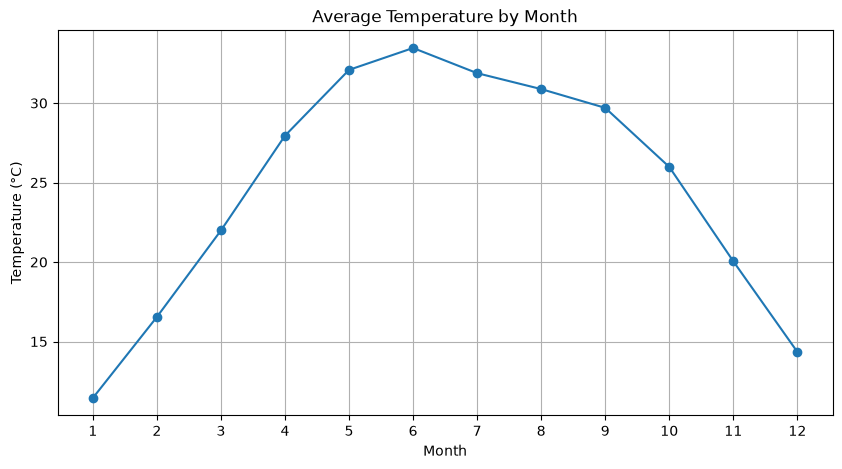

In [27]:
monthly_temp = df.groupby("month")["temperature"].mean()

monthly_temp.plot(figsize=(10, 5), marker="o")

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid()
plt.show()

In [28]:
df[["temperature", "humidity", "pressure"]].corr()

,temperature,humidity,pressure
temperature,1.000000,-0.611447,-0.800485
humidity,-0.611447,1.000000,0.254298
pressure,-0.800485,0.254298,1.000000


In [29]:
df = df.sort_values("timestamp").reset_index(drop=True)

In [30]:
df["temperature_change"] = df["temperature"].diff()
df["humidity_change"] = df["humidity"].diff()
df["pressure_change"] = df["pressure"].diff()

In [31]:
df["temperature_rolling_mean"] = (
    df["temperature"].rolling(24).mean()
)

df["temperature_rolling_std"] = (
    df["temperature"].rolling(24).std()
)

In [32]:
df["humidity_rolling_mean"] = (
    df["humidity"].rolling(24).mean()
)

df["humidity_rolling_std"] = (
    df["humidity"].rolling(24).std()
)

df["pressure_rolling_mean"] = (
    df["pressure"].rolling(24).mean()
)

df["pressure_rolling_std"] = (
    df["pressure"].rolling(24).std()
)

In [33]:
df["temperature_deviation"] = (
    df["temperature"] - df["temperature_rolling_mean"]
)

df["humidity_deviation"] = (
    df["humidity"] - df["humidity_rolling_mean"]
)

df["pressure_deviation"] = (
    df["pressure"] - df["pressure_rolling_mean"]
)

In [34]:
df.head(30)

,timestamp,temperature,humidity,pressure,hour,day,month,year,temperature_change,humidity_change,pressure_change,temperature_rolling_mean,temperature_rolling_std,humidity_rolling_mean,humidity_rolling_std,pressure_rolling_mean,pressure_rolling_std,temperature_deviation,humidity_deviation,pressure_deviation
0,2020-01-01 00:00:00,3.0,96,1021.5,0,1,1,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 01:00:00,2.5,97,1021.0,1,1,1,2020,-0.5,1.0,-0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 02:00:00,1.9,98,1021.0,2,1,1,2020,-0.6,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-01 03:00:00,1.7,98,1021.1,3,1,1,2020,-0.2,0.0,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-01 04:00:00,1.5,99,1021.1,4,1,1,2020,-0.2,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2020-01-01 05:00:00,2.0,98,1021.4,5,1,1,2020,0.5,-1.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2020-01-01 06:00:00,1.9,98,1021.7,6,1,1,2020,-0.1,0.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2020-01-01 07:00:00,1.7,98,1022.2,7,1,1,2020,-0.2,0.0,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2020-01-01 08:00:00,3.6,94,1022.7,8,1,1,2020,1.9,-4.0,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2020-01-01 09:00:00,6.6,85,1023.3,9,1,1,2020,3.0,-9.0,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
df.isnull().sum()

timestamp                    0
temperature                  0
humidity                     0
pressure                     0
hour                         0
day                          0
month                        0
year                         0
temperature_change           1
humidity_change              1
pressure_change              1
temperature_rolling_mean    23
temperature_rolling_std     23
humidity_rolling_mean       23
humidity_rolling_std        23
pressure_rolling_mean       23
pressure_rolling_std        23
temperature_deviation       23
humidity_deviation          23
pressure_deviation          23
dtype: int64

In [36]:
from scipy.stats import zscore

df["temperature_z"] = zscore(df["temperature"])
df["humidity_z"] = zscore(df["humidity"])
df["pressure_z"] = zscore(df["pressure"])

In [37]:
df["zscore_anomaly"] = (
    (df["temperature_z"].abs() > 3) |
    (df["humidity_z"].abs() > 3) |
    (df["pressure_z"].abs() > 3)
)

In [38]:
df["zscore_anomaly"].value_counts()

zscore_anomaly
False    43848
Name: count, dtype: int64

In [39]:
df[df["zscore_anomaly"]][
    ["timestamp", "temperature", "humidity", "pressure",
     "temperature_z", "humidity_z", "pressure_z"]
].head(20)

,timestamp,temperature,humidity,pressure,temperature_z,humidity_z,pressure_z


In [40]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper

In [41]:
temp_lower, temp_upper = iqr_bounds(df["temperature"])
hum_lower, hum_upper = iqr_bounds(df["humidity"])
pressure_lower, pressure_upper = iqr_bounds(df["pressure"])

print("Temperature:", temp_lower, "to", temp_upper)
print("Humidity:", hum_lower, "to", hum_upper)
print("Pressure:", pressure_lower, "to", pressure_upper)

Temperature: -1.9500000000000028 to 51.25
Humidity: -13.0 to 131.0
Pressure: 982.25 to 1034.65


In [42]:
df["iqr_anomaly"] = (
    (df["temperature"] < temp_lower) |
    (df["temperature"] > temp_upper) |
    (df["humidity"] < hum_lower) |
    (df["humidity"] > hum_upper) |
    (df["pressure"] < pressure_lower) |
    (df["pressure"] > pressure_upper)
)

In [43]:
df["iqr_anomaly"].value_counts()

iqr_anomaly
False    43848
Name: count, dtype: int64

In [44]:
print("Z-score anomalies:", df["zscore_anomaly"].sum())
print("IQR anomalies:", df["iqr_anomaly"].sum())

Z-score anomalies: 0
IQR anomalies: 0


In [45]:
pd.crosstab(
    df["zscore_anomaly"],
    df["iqr_anomaly"]
)

iqr_anomaly,False
zscore_anomaly,
False,43848


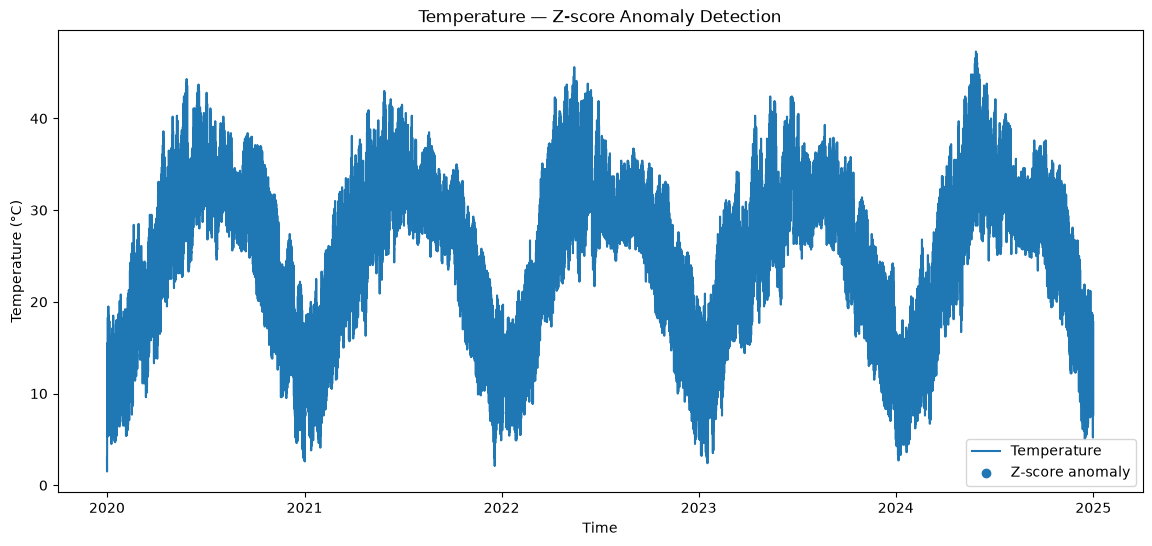

In [46]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["timestamp"],
    df["temperature"],
    label="Temperature"
)

anomalies = df[df["zscore_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["temperature"],
    label="Z-score anomaly"
)

plt.title("Temperature — Z-score Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [47]:
features = [
    "temperature",
    "humidity",
    "pressure",
    "hour",
    "month",
    "temperature_change",
    "humidity_change",
    "pressure_change",
    "temperature_rolling_mean",
    "temperature_rolling_std",
    "humidity_rolling_mean",
    "humidity_rolling_std",
    "pressure_rolling_mean",
    "pressure_rolling_std",
    "temperature_deviation",
    "humidity_deviation",
    "pressure_deviation"
]

In [48]:
ml_df = df.dropna(subset=features).copy()

In [49]:
print("Original rows:", len(df))
print("ML rows:", len(ml_df))

Original rows: 43848
ML rows: 43825


In [50]:
X = ml_df[features]

In [51]:
import sys
print(sys.executable)

from sklearn.ensemble import IsolationForest
print("Isolation Forest is ready!")

c:\Users\Sreoshi\anomaly-detection\.venv\Scripts\python.exe
Isolation Forest is ready!


In [52]:
model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

In [53]:
ml_df["isolation_prediction"] = model.fit_predict(X)

In [54]:
ml_df["isolation_anomaly"] = (
    ml_df["isolation_prediction"] == -1
)

In [55]:
ml_df["isolation_prediction"] = model.fit_predict(X)

ml_df["isolation_anomaly"] = (
    ml_df["isolation_prediction"] == -1
)

In [56]:
print("Isolation Forest anomalies:", ml_df["isolation_anomaly"].sum())

Isolation Forest anomalies: 5522


In [57]:
print(ml_df["isolation_anomaly"].value_counts())

isolation_anomaly
False    38303
True      5522
Name: count, dtype: int64


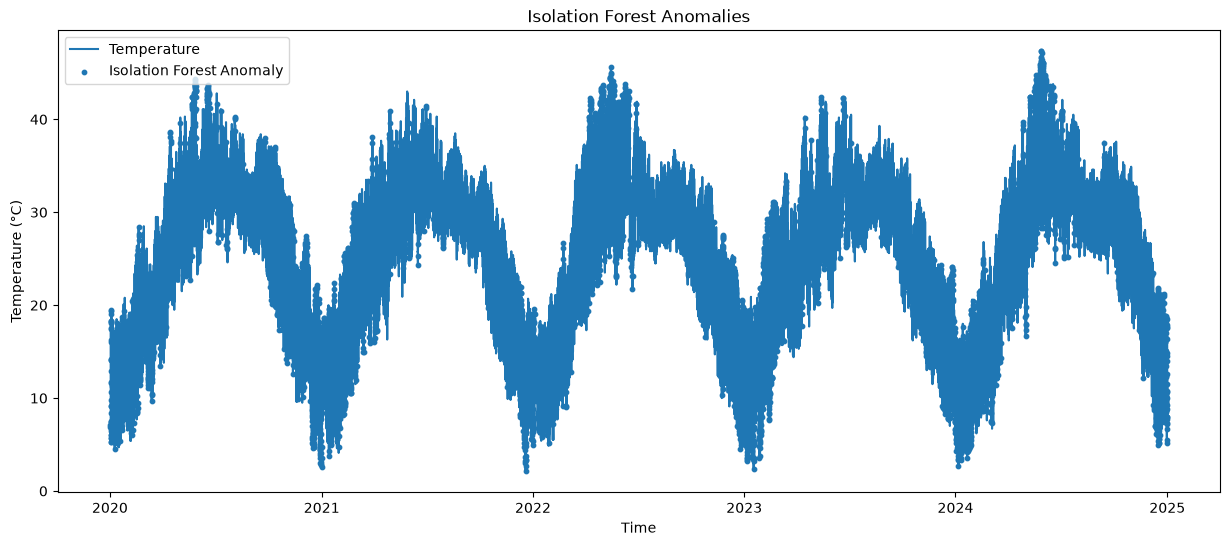

In [59]:
plt.figure(figsize=(15, 6))

plt.plot(
    ml_df["timestamp"],
    ml_df["temperature"],
    label="Temperature"
)

anomalies = ml_df[ml_df["isolation_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["temperature"],
    label="Isolation Forest Anomaly",
    s=10
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Isolation Forest Anomalies")
plt.legend()
plt.show()

In [60]:
ml_df["anomaly_score"] = model.decision_function(X)

In [61]:
ml_df["anomaly_score"].describe()

count    43825.000000
mean         0.036468
std          0.030488
min         -0.118312
25%          0.016968
50%          0.039996
75%          0.059527
max          0.106989
Name: anomaly_score, dtype: float64

In [62]:
ml_df[
    ["timestamp", "temperature", "humidity", "pressure", "anomaly_score"]
].sort_values("anomaly_score").head(10)

,timestamp,temperature,humidity,pressure,anomaly_score
21562,2022-06-17 10:00:00,25.5,84,1002.5,-0.118312
39978,2024-07-23 18:00:00,28.8,87,994.6,-0.107931
39450,2024-07-01 18:00:00,29.9,82,991.9,-0.105307
4108,2020-06-20 04:00:00,28.0,73,1000.3,-0.099829
12413,2021-06-01 05:00:00,25.2,75,1000.7,-0.099340
4637,2020-07-12 05:00:00,27.5,85,996.7,-0.098480
39198,2024-06-21 06:00:00,24.5,92,999.9,-0.094822
18065,2022-01-22 17:00:00,12.9,94,1003.3,-0.094703
38677,2024-05-30 13:00:00,45.7,7,996.3,-0.094315
20967,2022-05-23 15:00:00,26.6,72,995.1,-0.093987


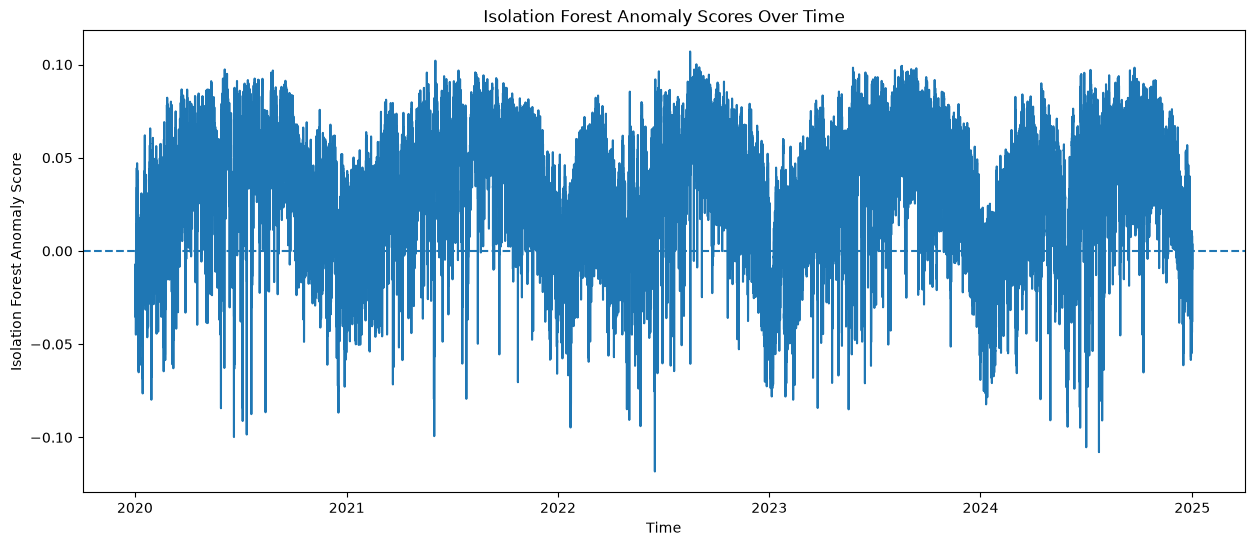

In [63]:
plt.figure(figsize=(15, 6))

plt.plot(
    ml_df["timestamp"],
    ml_df["anomaly_score"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Isolation Forest Anomaly Score")
plt.title("Isolation Forest Anomaly Scores Over Time")
plt.show()